# Loan Default Prediction

In [2]:
%load_ext autoreload
%autoreload 2

from scripts.utilities import *
from scripts.features import *

## 1. Load and Process Data

In [3]:
# Load raw data
consumer_df, account_df, transaction_df = get_data()

# Filter consumers with no transaction or balance information
consumer_df, account_df, transaction_df = filter_unknown(consumer_df, account_df, transaction_df)

Data successfully loaded and processed.


In [8]:
consumer_df

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0
...,...,...,...,...
14991,14991,2022-01-26,667.0,NaN
14992,14992,2022-03-14,709.0,NaN
14994,14994,2022-01-15,616.0,NaN
14996,14996,2022-01-15,625.0,NaN


In [6]:
account_df

,prism_consumer_id,prism_account_id,account_type,balance_date,balance
0,3023,0,SAVINGS,2021-08-31,90.57
1,3023,1,CHECKING,2021-08-31,225.95
2,4416,2,SAVINGS,2022-03-31,15157.17
3,4416,3,CHECKING,2022-03-31,66.42
4,4227,4,CHECKING,2021-07-31,7042.90
...,...,...,...,...,...
24461,11500,24461,CHECKING,2022-03-27,732.75
24462,11615,24462,SAVINGS,2022-03-30,5.00
24463,11615,24463,CHECKING,2022-03-30,1956.46
24464,12210,24464,CHECKING,2022-03-28,2701.51


In [3]:
# Define feature functions
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
    outflow_over_time_fix,
    balance_over_time
]

# Calculate features
feature_dataframes = execute_selected_features(selected_features, account_df, transaction_df)
final_features = merge_features(feature_dataframes)

# Merge with consumer data
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)


Feature Execution Plan:
- Total feature creation functions: 8
- Unchanged feature creation functions: 8 (using cached results)

No feature creation functions need to be executed.
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category
- Using cached result for outflow_stats
- Using cached result for outflow_over_time_fix
- Using cached result for balance_over_time

Total Created Features:  266


## 2 Split Data

In [4]:
# Split with validation set for hyperparameter tuning
train_df, _, test_df = split_data(ml_features, test_size=0.25)

# Define feature columns
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
all_feature_columns = [col for col in train_df.columns if col not in exclude_columns]

Training set size: 7591
No validation set created.
Test set size: 2531


## 3. Feature Selection

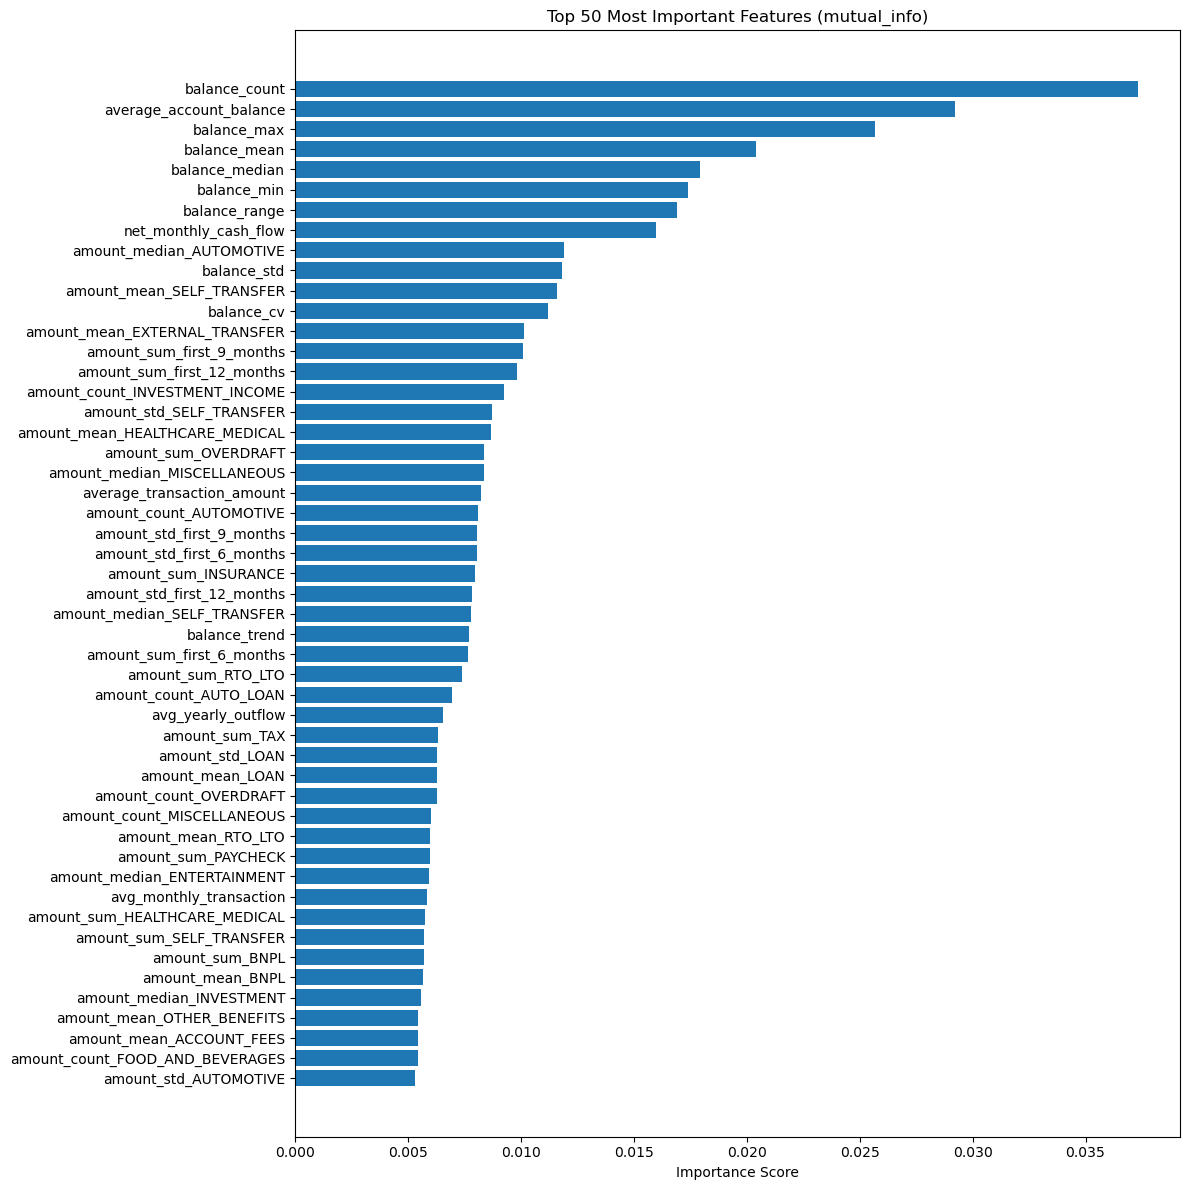

In [10]:
# Initialize the feature selector with your training DataFrame, feature columns, and any forced features.
fs = FeatureSelector(train_df, all_feature_columns)

# Run feature selection using the desired method(s)
# available --> ['mutual_info', 'random_forest', 'xgboost']
fs.run_feature_selection(methods=['mutual_info'], n_features=50)

# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Plot the importance scores for the selected method
fs.plot_feature_importance('mutual_info', top_n=50)

## 4. Model Performance

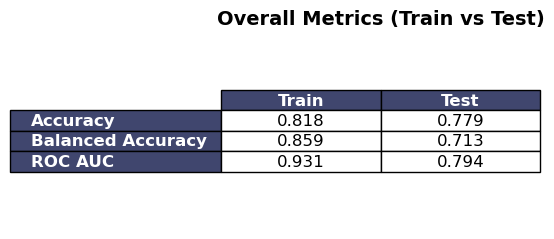


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.989416  0.809029  0.890176  6933.000000  0.960876  0.791917  0.868254  2326.000000
1.0           0.311134  0.908815  0.463566   658.000000  0.211726  0.634146  0.317460   205.000000
accuracy      0.817679  0.817679  0.817679     0.817679  0.779139  0.779139  0.779139     0.779139
macro avg     0.650275  0.858922  0.676871  7591.000000  0.586301  0.713032  0.592857  2531.000000
weighted avg  0.930622  0.817679  0.853197  7591.000000  0.900198  0.779139  0.823642  2531.000000


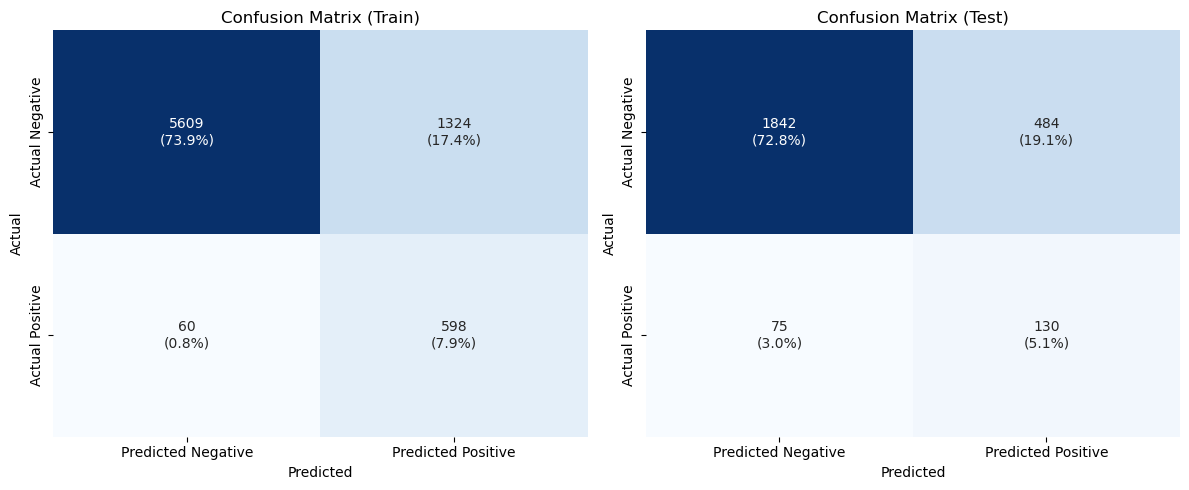

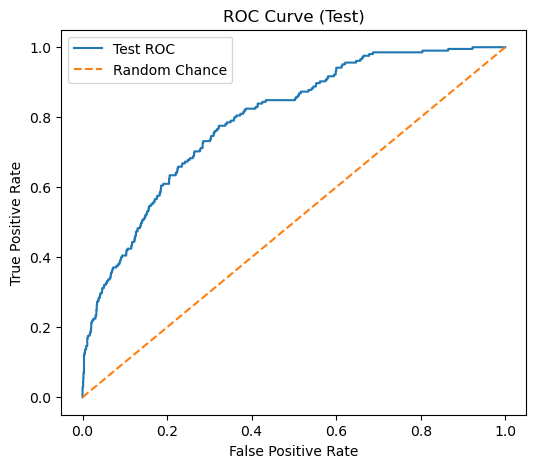

{'test': {'accuracy': 0.7791386803634927,
  'balanced_accuracy': 0.7130318981607702,
  'roc_auc': 0.7943701109410063,
  'roc_curve': {'fpr': array([0.        , 0.        , 0.        , 0.00128977, 0.00128977,
          0.00171969, 0.00171969, 0.00214961, 0.00214961, 0.00300946,
          0.00300946, 0.00343938, 0.00343938, 0.0038693 , 0.0038693 ,
          0.00472915, 0.00472915, 0.00558899, 0.00558899, 0.00601892,
          0.00601892, 0.00859845, 0.00859845, 0.01117799, 0.01117799,
          0.01160791, 0.01160791, 0.01289768, 0.01289768, 0.01676698,
          0.01676698, 0.01805675, 0.01805675, 0.01934652, 0.01934652,
          0.01977644, 0.01977644, 0.02063629, 0.02063629, 0.02106621,
          0.02106621, 0.0227859 , 0.0227859 , 0.02579536, 0.02579536,
          0.03052451, 0.03052451, 0.03095443, 0.03095443, 0.03267412,
          0.03267412, 0.03353396, 0.03353396, 0.03439381, 0.03439381,
          0.03740327, 0.03740327, 0.03783319, 0.03783319, 0.04041273,
          0.04041273, 

In [6]:
# Initialize and train model with all features
model, scaler = train_model(train_df, all_feature_columns, "xgboost")
predict_and_analyze_model(model, scaler, train_df, test_df, all_feature_columns)

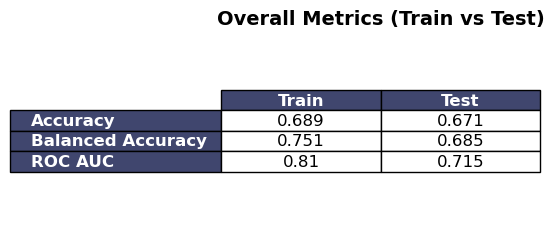


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.976067  0.676475  0.799114  6933.000000  0.962229  0.668100  0.788632  2326.000000
1.0           0.194903  0.825228  0.315331   658.000000  0.157205  0.702439  0.256913   205.000000
accuracy      0.689369  0.689369  0.689369     0.689369  0.670881  0.670881  0.670881     0.670881
macro avg     0.585485  0.750851  0.557222  7591.000000  0.559717  0.685269  0.522773  2531.000000
weighted avg  0.908354  0.689369  0.757179  7591.000000  0.897026  0.670881  0.745565  2531.000000


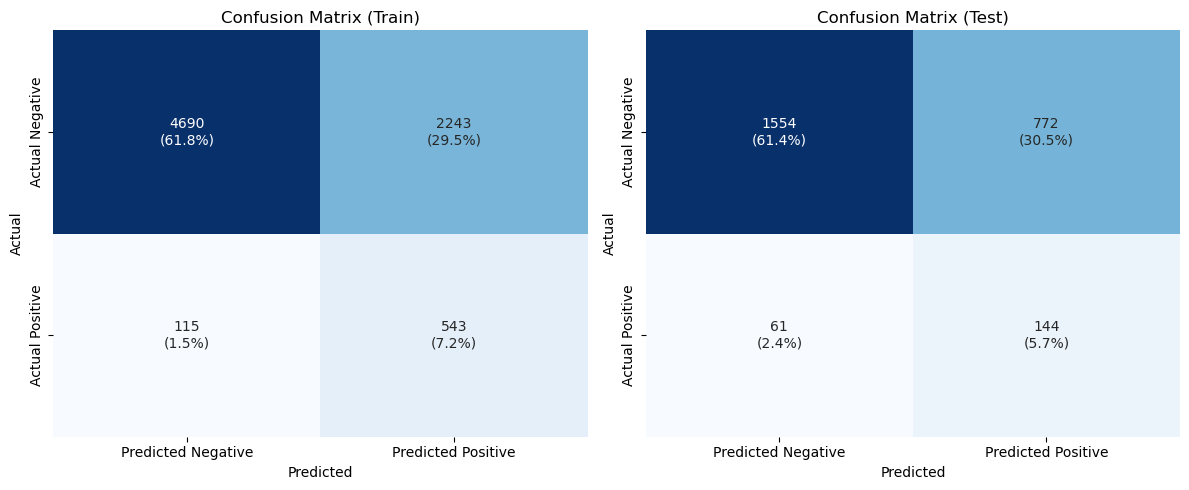

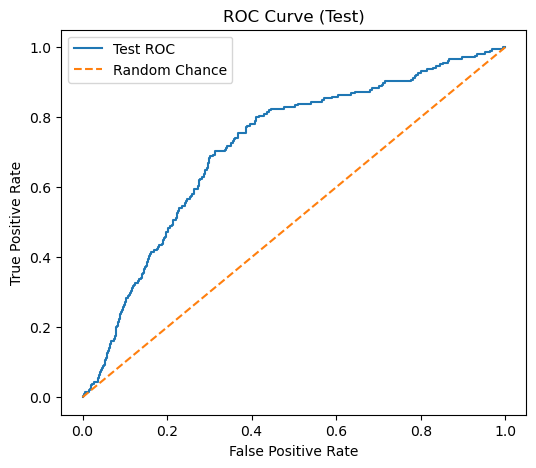

{'test': {'accuracy': 0.6708810746740419,
  'balanced_accuracy': 0.6852693832183377,
  'roc_auc': 0.7145292871673343,
  'roc_curve': {'fpr': array([0.00000000e+00, 4.29922614e-04, 1.71969046e-03, 1.71969046e-03,
          3.86930353e-03, 3.86930353e-03, 4.72914875e-03, 4.72914875e-03,
          1.50472915e-02, 1.50472915e-02, 1.80567498e-02, 1.80567498e-02,
          2.06362855e-02, 2.06362855e-02, 2.10662081e-02, 2.10662081e-02,
          2.23559759e-02, 2.23559759e-02, 2.79449699e-02, 2.79449699e-02,
          3.56835770e-02, 3.56835770e-02, 3.61134996e-02, 3.61134996e-02,
          3.78331900e-02, 3.78331900e-02, 3.95528805e-02, 3.95528805e-02,
          4.12725709e-02, 4.12725709e-02, 4.21324162e-02, 4.21324162e-02,
          4.29922614e-02, 4.29922614e-02, 4.60017197e-02, 4.60017197e-02,
          4.81513328e-02, 4.81513328e-02, 5.11607911e-02, 5.11607911e-02,
          5.28804815e-02, 5.28804815e-02, 5.33104041e-02, 5.33104041e-02,
          5.37403267e-02, 5.37403267e-02, 5.5460

In [7]:
# Initialize and train model with all features
model, scaler = train_model(train_df, all_feature_columns, "logistic")
predict_and_analyze_model(model, scaler, train_df, test_df, all_feature_columns)

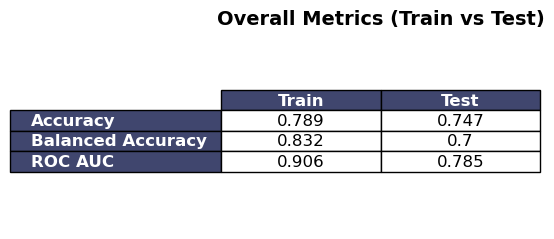


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.986139  0.779893  0.870973  6933.000000  0.960153  0.756234  0.846080  2326.000000
1.0           0.276091  0.884498  0.420824   658.000000  0.188841  0.643902  0.292035   205.000000
accuracy      0.788961  0.788961  0.788961     0.788961  0.747136  0.747136  0.747136     0.747136
macro avg     0.631115  0.832196  0.645899  7591.000000  0.574497  0.700068  0.569058  2531.000000
weighted avg  0.924591  0.788961  0.831953  7591.000000  0.897680  0.747136  0.801205  2531.000000


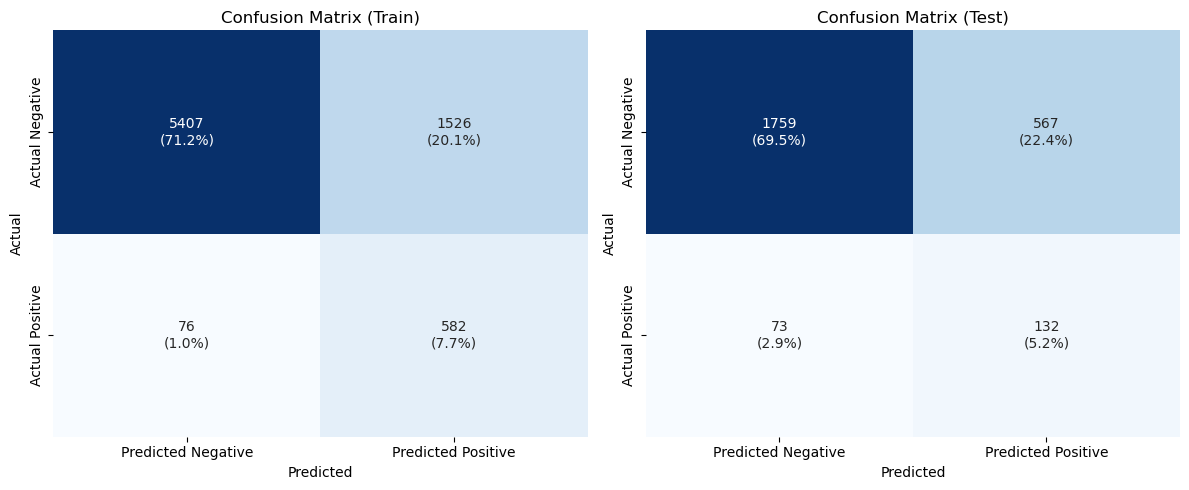

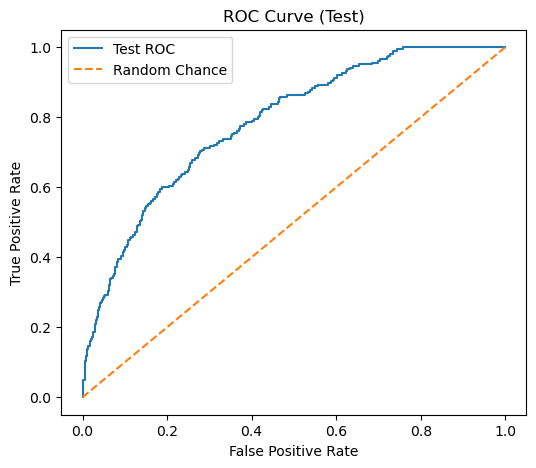

{'test': {'accuracy': 0.7471355195574871,
  'balanced_accuracy': 0.7000681584631839,
  'roc_auc': 0.7846716859258016,
  'roc_curve': {'fpr': array([0.00000000e+00, 4.29922614e-04, 4.29922614e-04, 8.59845228e-04,
          8.59845228e-04, 1.28976784e-03, 1.28976784e-03, 1.71969046e-03,
          1.71969046e-03, 2.14961307e-03, 2.14961307e-03, 4.72914875e-03,
          4.72914875e-03, 5.15907137e-03, 5.15907137e-03, 5.58899398e-03,
          5.58899398e-03, 6.44883921e-03, 6.44883921e-03, 6.87876182e-03,
          6.87876182e-03, 7.30868444e-03, 7.30868444e-03, 9.88822012e-03,
          9.88822012e-03, 1.03181427e-02, 1.03181427e-02, 1.20378332e-02,
          1.20378332e-02, 1.37575236e-02, 1.37575236e-02, 1.67669819e-02,
          1.67669819e-02, 1.71969046e-02, 1.71969046e-02, 1.76268272e-02,
          1.76268272e-02, 1.93465176e-02, 1.93465176e-02, 2.19260533e-02,
          2.19260533e-02, 2.36457438e-02, 2.36457438e-02, 2.53654342e-02,
          2.53654342e-02, 2.92347377e-02, 2.9234

In [8]:
# Initialize and train model with best features
model, scaler = train_model(train_df, feature_columns, "xgboost")
predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)

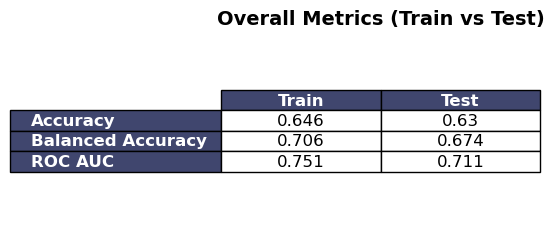


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.967841  0.633780  0.765972  6933.000000  0.962692  0.621238  0.755161  2326.000000
1.0           0.167814  0.778116  0.276085   658.000000  0.144660  0.726829  0.241296   205.000000
accuracy      0.646292  0.646292  0.646292     0.646292  0.629791  0.629791  0.629791     0.629791
macro avg     0.567828  0.705948  0.521029  7591.000000  0.553676  0.674034  0.498228  2531.000000
weighted avg  0.898494  0.646292  0.723508  7591.000000  0.896435  0.629791  0.713540  2531.000000


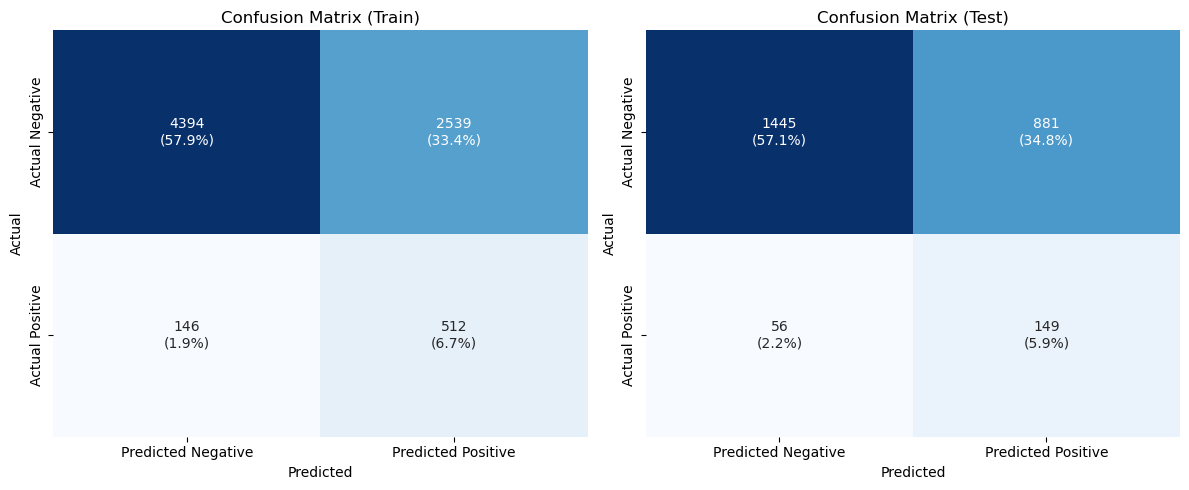

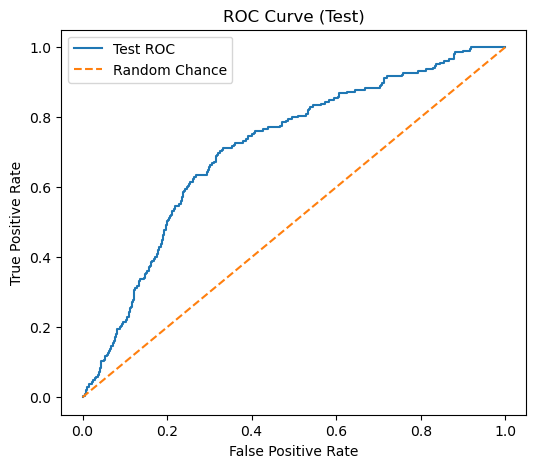

{'test': {'accuracy': 0.6297905966021335,
  'balanced_accuracy': 0.6740337227103999,
  'roc_auc': 0.710804689302267,
  'roc_curve': {'fpr': array([0.00000000e+00, 4.29922614e-04, 8.59845228e-04, 8.59845228e-04,
          6.44883921e-03, 6.44883921e-03, 9.02837489e-03, 9.02837489e-03,
          9.45829751e-03, 9.45829751e-03, 1.03181427e-02, 1.03181427e-02,
          1.46173689e-02, 1.46173689e-02, 1.50472915e-02, 1.50472915e-02,
          2.27858985e-02, 2.27858985e-02, 2.49355116e-02, 2.49355116e-02,
          2.83748925e-02, 2.83748925e-02, 3.26741187e-02, 3.26741187e-02,
          3.65434222e-02, 3.65434222e-02, 3.78331900e-02, 3.78331900e-02,
          4.04127257e-02, 4.04127257e-02, 4.17024936e-02, 4.17024936e-02,
          4.29922614e-02, 4.29922614e-02, 4.42820292e-02, 4.42820292e-02,
          5.03009458e-02, 5.03009458e-02, 5.33104041e-02, 5.33104041e-02,
          5.37403267e-02, 5.46001720e-02, 5.76096303e-02, 5.76096303e-02,
          6.06190886e-02, 6.06190886e-02, 6.14789

In [9]:
# Initialize and train model with best features
model, scaler = train_model(train_df, feature_columns, "logistic")
predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)